# Stage 8: Monitoring (PSI / stability)

Input: the committed result tables `artifacts/monitoring_*.csv` (written by `python -m src.monitoring`).
The notebook reads only those tables and writes nothing except the figure.

Design (decision log D-028, agreed before the first run):
- **Baseline:** in-scope development loans, with bins frozen on development data.
- **Monitored sample:** the hold-out, standing in for a "next period". Only its **inputs and
  scores** are read, never its outcomes (D-025). No change to the model or the grades may follow
  from these results without approval.
- **Thresholds:** PSI / CSI ≤ 0.10 green, ≤ 0.25 amber, > 0.25 red. This is a conventional rule
  of thumb (HEURISTIC), not a regulatory standard.

**What this cannot show.** `year` is 2019 for every loan (D-004), and the split is random and
stratified (D-013). There is no later period, so there is no drift to detect, and two random
samples of one population give a PSI close to zero *by construction*. A green result shows the
monitoring works. **It is not evidence that the model is stable over time.**

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import config


def artifact(name: str) -> pd.DataFrame:
    return pd.read_csv(config.ARTIFACTS_DIR / f"{config.MONITORING_ARTIFACT_PREFIX}{name}.csv")


plt.rcParams.update({
    "axes.edgecolor": config.COLOR_INK_MUTED, "axes.labelcolor": config.COLOR_INK,
    "xtick.color": config.COLOR_INK_MUTED, "ytick.color": config.COLOR_INK_MUTED,
    "axes.grid": True, "grid.color": config.COLOR_GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": config.COLOR_SURFACE, "axes.facecolor": config.COLOR_SURFACE,
})

## 1. PSI of the score, the grades and the model features

PSI = Σ (monitored share − baseline share) × ln(monitored share / baseline share), over frozen
development bins. The chi-square column is a sample-size reference: with no shift,
PSI × n₁n₂/(n₁+n₂) is approximately χ² with (bins − 1) degrees of freedom. It is reported without
a judgement.

In [2]:
psi = artifact("psi").set_index("variable")
print(psi.round(6).to_string())

assert (psi["n_baseline"] == 93_391).all() and (psi["n_monitored"] == 39_981).all()
assert (psi["light"] == "green").all()
assert psi["psi"].max() < 0.001
assert round(psi.loc["score", "psi"], 4) == 0.0004
assert round(psi.loc["score", "psi_expected_no_shift"], 4) == 0.0003
assert round(psi.loc["income_clean", "psi"], 4) == 0.0006
assert (psi["chi2_p_value"] > 0.05).all()  # no PSI is larger than sampling noise would explain
assert psi.loc["income_clean", "n_bins_used"] == 11  # 10 deciles + a missing bin

                      role  n_bins_used  n_baseline  n_monitored       psi  psi_expected_no_shift  chi2_statistic  chi2_df  chi2_p_value  light
variable                                                                                                                                       
score                score           10       93391        39981  0.000399               0.000321       11.164827        9      0.264580  green
loan_amount        feature           10       93391        39981  0.000320               0.000321        8.962225        9      0.440768  green
income_clean       feature           11       93391        39981  0.000580               0.000357       16.245741       10      0.092811  green
grade                grade            8       93391        39981  0.000293               0.000250        8.189789        7      0.316156  green
lump_sum_payment   feature            2       93391        39981  0.000013               0.000036        0.373294        1      0.541214

**Reading:** every PSI is below 0.001, more than 100 times below the 0.10 green limit. The
score's PSI (0.0004) is close to the 0.0003 expected from sampling noise alone. No chi-square
p-value is below 0.05, so none of the differences is larger than random sampling explains. This is
the expected result for a random split (D-013). It confirms that the binning and the SQL work
end-to-end. It says nothing about stability over time (D-004).

## 2. Grade shares (D-027 concentration)

In [3]:
bins = artifact("psi_bins")
special = [config.MISSING_BIN_LABEL, config.UNSEEN_BIN_LABEL]
grade_rows = bins[bins["variable"] == config.MONITORING_GRADE_VARIABLE]
grade_bins = grade_rows[~grade_rows["bin_label"].isin(special)]
print(grade_bins[["bin_label", "n_baseline", "n_monitored", "share_baseline", "share_monitored", "psi_contribution"]]
      .round(4).to_string(index=False))

a = grade_bins.set_index("bin_label").loc["A"]
assert round(a["share_baseline"], 3) == 0.450 and round(a["share_monitored"], 3) == 0.449
assert (grade_rows.loc[grade_rows["bin_label"].isin(special), "n_monitored"] == 0).all()

bin_label  n_baseline  n_monitored  share_baseline  share_monitored  psi_contribution
        A       42029        17951          0.4500           0.4490            0.0000
        B        9341         3979          0.1000           0.0995            0.0000
        C        9340         4158          0.1000           0.1040            0.0002
        D        9327         4062          0.0999           0.1016            0.0000
        E        4675         1979          0.0501           0.0495            0.0000
        F        4670         2002          0.0500           0.0501            0.0000
        G        9339         3914          0.1000           0.0979            0.0000
        H        4670         1936          0.0500           0.0484            0.0001


**Reading:** grade A holds 45.0% of development loans and 44.9% of hold-out loans. Every
other grade's share is also within a fraction of a point. The grade PSI cannot see shifts *inside*
grade A; the score PSI, binned on development deciles, covers those.

## 3. Watch list (D-023, D-026, D-027)

In [4]:
watch = artifact("watch_list").set_index("kpi")
print(watch.round(4).to_string())

assert (watch["light"] == "green").all()
assert round(watch.loc["top_decile_share_loan_amount", "baseline_value"], 3) == 0.101
assert round(watch.loc["top_decile_share_income_clean", "baseline_value"], 3) == 0.094
assert round(watch.loc["out_of_scope_share", "baseline_value"], 4) == 0.1026
assert round(watch.loc["out_of_scope_share", "monitored_value"], 4) == 0.1036
assert round(watch.loc["share_lump_sum_payment_lpsm", "baseline_value"], 4) == 0.0165
assert watch.loc["n_unseen_levels", "monitored_value"] == 0

                              decision  baseline_value  monitored_value                                  rule  light
kpi                                                                                                                 
top_decile_share_loan_amount     D-023          0.1006           0.0983           green <= 0.15, amber <= 0.2  green
top_decile_share_income_clean    D-023          0.0941           0.0927           green <= 0.15, amber <= 0.2  green
grade_A_share_change             D-027          0.4500           0.4490  |change| green <= 0.05, amber <= 0.1  green
out_of_scope_share               D-026          0.1026           0.1036           green <= 0.15, amber <= 0.2  green
share_lump_sum_payment_lpsm      D-023          0.0165           0.0170             green >= 0.01, else amber  green
n_unseen_levels                  D-023          0.0000           0.0000                   green = 0, else red  green


**Reading:**
- The top `loan_amount` decile bin holds 10.1% of development loans. The top `income_clean` bin
  holds 9.4%, because 7.1% of incomes are missing and have their own bin. The hold-out matches both.
- The out-of-scope (EQUI) share is 10.3% and 10.4%.
- `lpsm` stays above the 1% rare-level rule (1.65%), and no unseen level appears.

The outcome-based half of the D-023 and D-027 watch items needs defaults from a new period:
- the observed-minus-predicted gap in the top deciles;
- grade A's observed rate against its grade PD.

That cannot be computed here.

## 4. Characteristic analysis: which feature moves the score?

In [5]:
char = artifact("characteristic").set_index("feature")
print(char.round(5).to_string())

terms = char.drop("total")["change_in_log_odds"]
assert abs(terms.sum() - char.loc["total", "change_in_log_odds"]) < 1e-5
assert round(char.loc["total", "change_in_log_odds"], 4) == -0.0025
assert terms.abs().idxmax() == "Neg_ammortization"

                   baseline_contribution  monitored_contribution  change_in_log_odds
feature                                                                             
income_clean                    -0.01551                -0.01505             0.00046
loan_amount                     -0.00000                 0.00026             0.00026
lump_sum_payment                 0.04106                 0.04223             0.00117
Neg_ammortization                0.11097                 0.10700            -0.00397
loan_type                        0.08570                 0.08596             0.00026
loan_purpose                    -0.03261                -0.03324            -0.00063
total                            0.18962                 0.18716            -0.00246


**Reading:** the mean log-odds differs by −0.0025 between the samples. The largest single term
is `Neg_ammortization` (−0.004): the hold-out has slightly fewer negatively amortising loans. All
of these differences are tiny. In a real monitoring cycle, this table would show which
characteristic drives any score shift.

## 5. Per-grade backtest: development reference only

Per-grade default rates need outcomes, so they are computed on **development** loans only
(D-028, option a): in-sample, and out-of-fold from the Stage 5 folds. They are the reference a
future backtest would be compared with. Lights reuse the D-025 thresholds. In-sample they are a
reference, not a judgement: the grade PD was set on the same loans (D-027).

In [6]:
backtest = artifact("grade_backtest")
print(backtest.round(4).to_string(index=False))

assert set(backtest["sample"]) == {"development_in_sample", "development_out_of_fold"}
ins = backtest[backtest["sample"] == "development_in_sample"].set_index("grade")
assert ins["n_loans"].sum() == 93_391
assert (ins["gap"].abs() <= 0.05).all()
assert ins.loc["F", "gap_light"] == "amber" and round(ins.loc["F", "gap"], 4) == 0.0226
assert set(ins.index[ins["binomial_light"] == "red"]) == {"B", "F", "H"}

                 sample grade  grade_pd  n_loans  n_defaults  observed_rate     gap  binomial_p gap_light binomial_light
  development_in_sample     A    0.0950    42029        4034         0.0960  0.0010      0.4692     green          green
  development_in_sample     B    0.1282     9341        1017         0.1089 -0.0193      0.0000     green            red
  development_in_sample     C    0.1437     9340        1317         0.1410 -0.0027      0.4609     green          green
  development_in_sample     D    0.1641     9327        1471         0.1577 -0.0063      0.0990     green          green
  development_in_sample     E    0.1852     4675         821         0.1756 -0.0095      0.0938     green          green
  development_in_sample     F    0.2108     4670        1090         0.2334  0.0226      0.0002     amber            red
  development_in_sample     G    0.2831     9339        2719         0.2911  0.0080      0.0849     green          green
  development_in_sample     H   

**Reading:** in-sample, every grade's observed rate is within 2.3 pp of its grade PD. F is
amber on the gap (2.3 pp above its grade PD), and B, F and H have binomial p < 0.01, as Stage 7
reported (D-027). The out-of-fold figures are almost the same. These are the development reference
values, not a validation result.

## 6. Figure

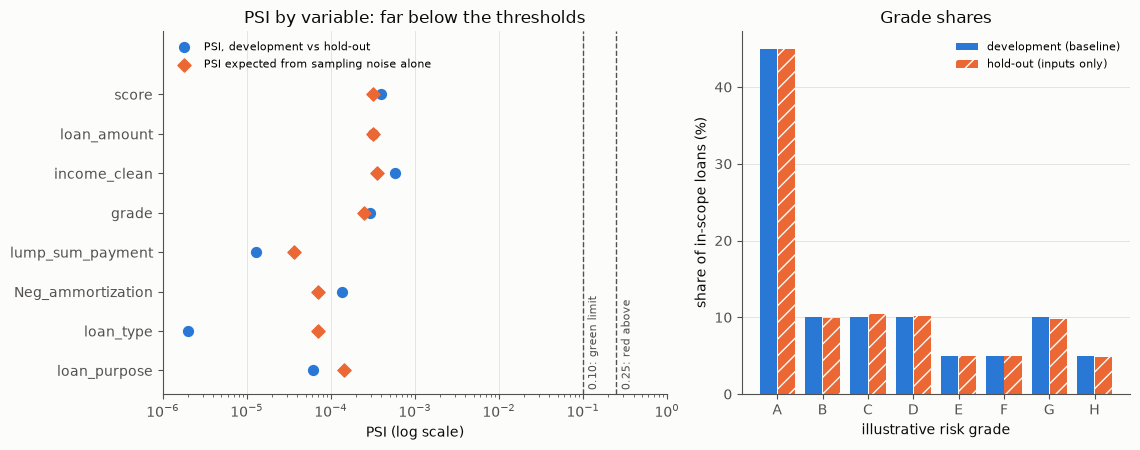

In [7]:
order = config.MONITORING_NUMERIC_VARIABLES + config.MONITORING_CATEGORICAL_VARIABLES
plot = psi.loc[order[::-1]]
y = np.arange(len(plot))
green, amber = config.PSI_THRESHOLDS

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.6), gridspec_kw={"width_ratios": [1.3, 1]})
ax1.scatter(plot["psi"], y, color=config.COLOR_PRIMARY, s=50, marker="o", zorder=3,
            label="PSI, development vs hold-out")
ax1.scatter(plot["psi_expected_no_shift"], y, color=config.COLOR_SECONDARY, s=45, marker="D", zorder=3,
            label="PSI expected from sampling noise alone")
for limit, name in [(green, "0.10: green limit"), (amber, "0.25: red above")]:
    ax1.axvline(limit, color=config.COLOR_INK_MUTED, linewidth=1, linestyle="--")
    ax1.annotate(name, (limit, -0.5), xytext=(3, 0), textcoords="offset points", rotation=90,
                 ha="left", va="bottom", color=config.COLOR_INK_MUTED, fontsize=8)
ax1.set_xscale("log")
ax1.set_xlim(1e-6, 1)
ax1.set_ylim(-0.6, len(plot) + 0.6)
ax1.set_yticks(y, plot.index)
ax1.set_xlabel("PSI (log scale)")
ax1.set_title("PSI by variable: far below the thresholds", color=config.COLOR_INK)
ax1.legend(frameon=False, loc="upper left", fontsize=8)
ax1.grid(axis="y", visible=False)

labels = grade_bins["bin_label"].tolist()
x = np.arange(len(labels))
w = 0.38
ax2.bar(x - w / 2 - 0.01, grade_bins["share_baseline"] * 100, width=w, color=config.COLOR_PRIMARY,
        label="development (baseline)")
ax2.bar(x + w / 2 + 0.01, grade_bins["share_monitored"] * 100, width=w, color=config.COLOR_SECONDARY,
        hatch="//", edgecolor=config.COLOR_SURFACE, linewidth=0, label="hold-out (inputs only)")
ax2.set_xticks(x, labels)
ax2.set_xlabel("illustrative risk grade")
ax2.set_ylabel("share of in-scope loans (%)")
ax2.set_title("Grade shares", color=config.COLOR_INK)
ax2.legend(frameon=False, loc="upper right", fontsize=8)
ax2.grid(axis="x", visible=False)
ax2.set_axisbelow(True)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "13_monitoring_psi.png", dpi=config.FIGURE_DPI)
plt.show()

## 7. Scope

In [8]:
scope = artifact("scope").set_index("sample")
print(scope.to_string())
assert scope["n_out_of_scope_equi"].tolist() == [10_678, 4_620]
assert (scope["n_in_scope_not_graded"] == 0).all()

             n_loans  n_graded  n_out_of_scope_equi  n_in_scope_not_graded  out_of_scope_share
sample                                                                                        
development   104069     93391                10678                      0            0.102605
holdout        44601     39981                 4620                      0            0.103585


## 8. Conclusion

- **The monitoring runs end-to-end.** It builds a frozen development baseline in DuckDB, bins every
  scored loan with a SQL range join, and computes the PSI per bin in SQL. Tests check the SQL
  against an independent Python computation.
- **Every PSI and CSI is green and below 0.001**, close to the value expected from sampling noise
  alone. That is what a random split must give (D-013). **It is not evidence of stability over
  time:** the data has no time dimension (D-004).
- **Watch list:**
  - top-decile shares (D-023): 10.1% and 9.4% development, the same in the hold-out;
  - grade A share (D-027): 45.0% and 44.9%;
  - out-of-scope share (D-026): 10.3% and 10.4%;
  - `lpsm` share: 1.65%; no unseen levels.

  Everything is green.
- **No hold-out outcome was read** (D-025). `tests/test_monitoring.py` flips every hold-out
  `Status` and confirms that no Stage 8 table changes.
- What a real monitoring cycle would add: new time-stamped applications, realised defaults for
  backtesting, and the actions in `docs/monitoring_plan.md`.